In [2]:
import pandas as pd

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

d:\forecasting_system\project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [4]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

df['Date'] = pd.to_datetime(df['Date'])

In [5]:
state_df = df[df['State'] == 'California'].copy()

In [6]:
state_df = state_df[['Date', 'Sales']]

state_df = state_df.rename(
    columns={
        'Date': 'ds',
        'Sales': 'y'
    }
)

In [7]:
state_df = state_df.sort_values('ds')

In [8]:
forecast_horizon = 56

In [9]:
train = state_df.iloc[:-forecast_horizon]

In [10]:
valid = state_df.iloc[-forecast_horizon:]

In [11]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [12]:
model.add_country_holidays(country_name='US')

In [13]:
model.fit(train)

14:05:45 - cmdstanpy - INFO - Chain [1] start processing
14:05:46 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future = model.make_future_dataframe(
    periods=forecast_horizon
)

In [15]:
forecast = model.predict(future)

In [16]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
182,2022-05-31,8.826757e+08,8.108459e+08,9.543790e+08
183,2022-06-01,9.689976e+08,8.956327e+08,1.040345e+09
184,2022-06-02,8.570061e+08,7.824134e+08,9.288863e+08
185,2022-06-03,8.463917e+08,7.655795e+08,9.133431e+08
186,2022-06-04,9.328578e+08,8.605505e+08,1.006005e+09


In [17]:
predictions = forecast[['ds', 'yhat']].tail(forecast_horizon)

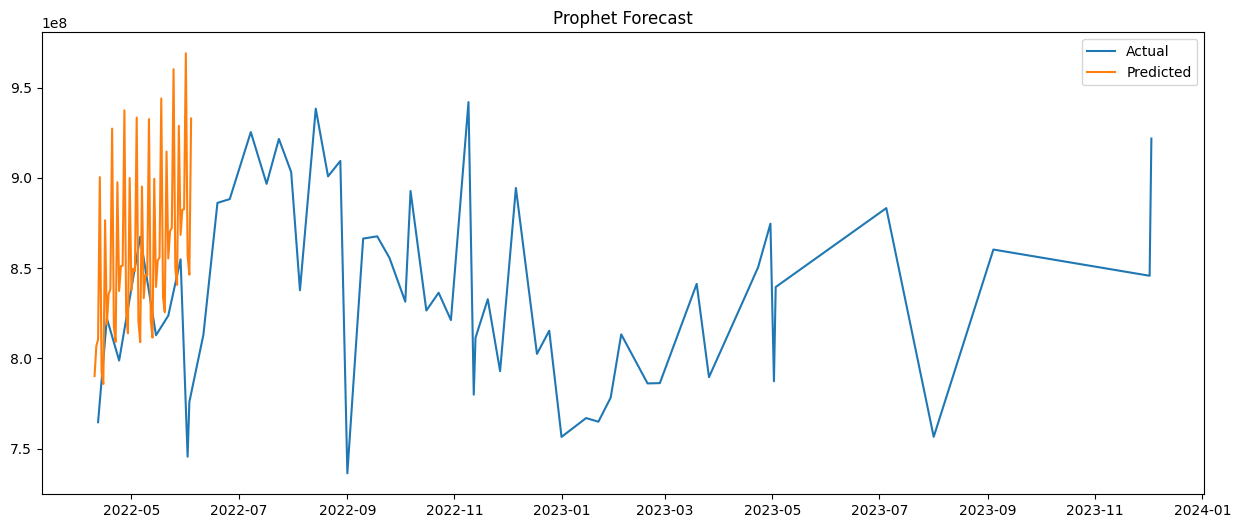

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    valid['ds'],
    valid['y'],
    label='Actual'
)

plt.plot(
    predictions['ds'],
    predictions['yhat'],
    label='Predicted'
)

plt.legend()

plt.title("Prophet Forecast")

plt.show()

In [19]:
mae = mean_absolute_error(
    valid['y'],
    predictions['yhat']
)

print("MAE:", mae)

MAE: 54073398.30620886


In [20]:
rmse = np.sqrt(
    mean_squared_error(
        valid['y'],
        predictions['yhat']
    )
)

print("RMSE:", rmse)

RMSE: 72618561.96624859


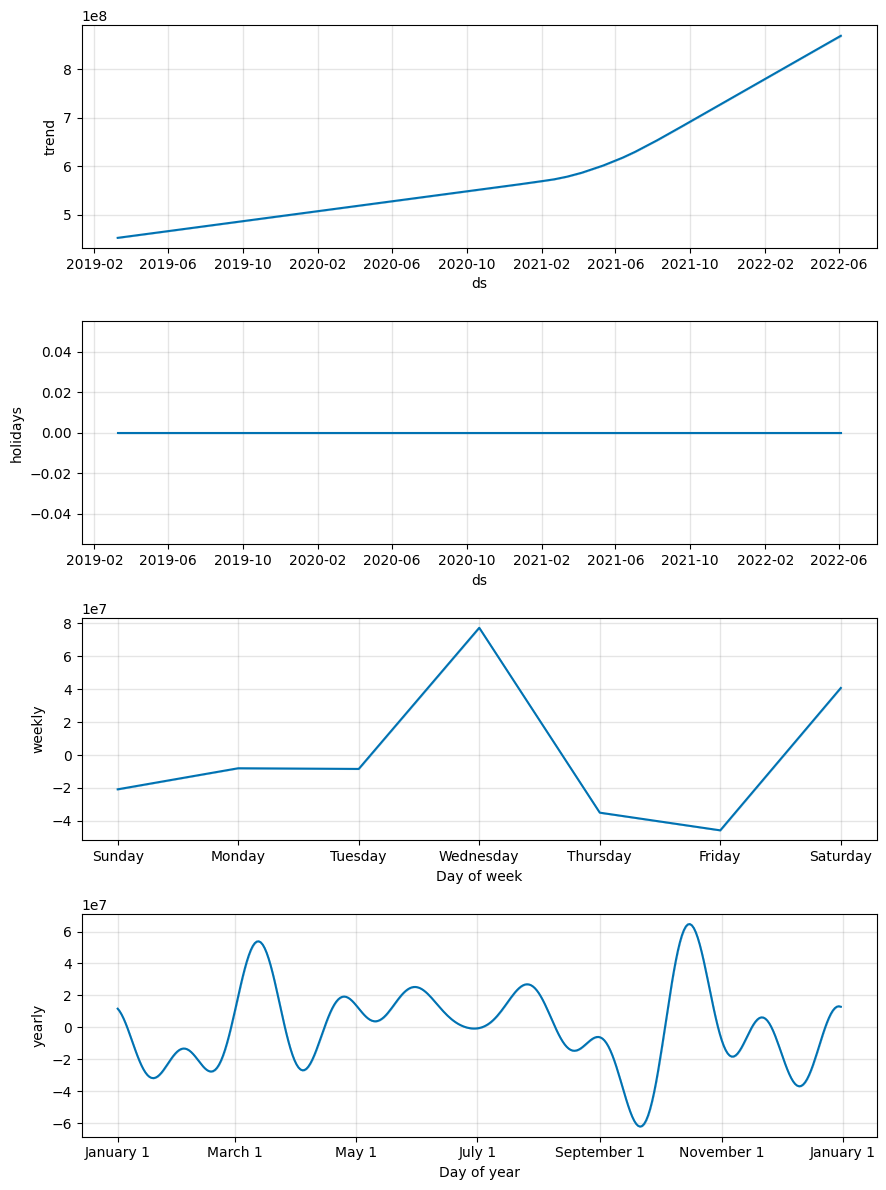

In [21]:
model.plot_components(forecast)

plt.show()

In [22]:
results = {
    'Model': 'Prophet',
    'MAE': mae,
    'RMSE': rmse
}

print(results)

{'Model': 'Prophet', 'MAE': 54073398.30620886, 'RMSE': np.float64(72618561.96624859)}


In [23]:
mape = np.mean(
    np.abs(
        (valid['y'] - predictions['yhat']) / valid['y']
    )
) * 100

print("MAPE:", mape)

MAPE: nan


In [24]:
import joblib

joblib.dump(
    model,
    "../models/prophet_model.pkl"
)

['../models/prophet_model.pkl']

In [25]:
results_df = pd.DataFrame([results])

results_df.to_csv(
    "../outputs/prophet_metrics.csv",
    index=False
)